In [ ]:
!pip install snowflake-connector-python pandas sci-kit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.8/84.8 kB 2.3 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of pyopenssl to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.0/105.0 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 62.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 4.1 MB/s eta 0:00:00
  Attempting uninstall: cryptography
    Found existing installation: cryptography 43.0.3
    Uninstalling cryptography-43.0.3:
      Successfully uninstalled cryptography-43.0.3
  Attempting uninstall: pyOpenSSL
    Found ex

In [ ]:
import snowflake.connector
import pandas as pd

In [ ]:
con=snowflake.connector.connect(
    user='Shivaji',
    password='Shivaji11042007',
    account='PLFONYJ-PV16555',
    database='water',
    schema="PUBLIC",
    warehouse='COMPUTE_WH'
)

In [ ]:
query="SELECT  * FROM waterdb"
df=pd.read_sql(query,con)

/tmp/ipykernel_4907/3659589878.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql(query,con)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PH               2785 non-null   float64
 1   HARDNESS         3276 non-null   float64
 2   SOLIDS           3276 non-null   float64
 3   CHLORAMINES      3276 non-null   float64
 4   SULFATE          2495 non-null   float64
 5   CONDUCTIVITY     3276 non-null   float64
 6   ORGANIC_CARBON   3276 non-null   float64
 7   TRIHALOMETHANES  3114 non-null   float64
 8   TURBIDITY        3276 non-null   float64
 9   POTABILITY       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [ ]:
df.isnull().sum()

,0
PH,491
HARDNESS,0
SOLIDS,0
CHLORAMINES,0
SULFATE,781
CONDUCTIVITY,0
ORGANIC_CARBON,0
TRIHALOMETHANES,162
TURBIDITY,0
POTABILITY,0


In [ ]:
nullval=['PH','SULFATE','TRIHALOMETHANES']

In [ ]:
for i in nullval:
  df[i]=df[i].fillna(df[i]).mean()

In [ ]:
df

,PH,HARDNESS,SOLIDS,CHLORAMINES,SULFATE,CONDUCTIVITY,ORGANIC_CARBON,TRIHALOMETHANES,TURBIDITY,POTABILITY
0,7.080795,204.890455,20791.318981,7.300212,333.775777,564.308654,10.379783,66.396293,2.963135,0
1,7.080795,129.422921,18630.057858,6.635246,333.775777,592.885359,15.180013,66.396293,4.500656,0
2,7.080795,224.236259,19909.541732,9.275884,333.775777,418.606213,16.868637,66.396293,3.055934,0
3,7.080795,214.373394,22018.417441,8.059332,333.775777,363.266516,18.436524,66.396293,4.628771,0
4,7.080795,181.101509,17978.986339,6.546600,333.775777,398.410813,11.558279,66.396293,4.075075,0
...,...,...,...,...,...,...,...,...,...,...
3271,7.080795,193.681735,47580.991603,7.166639,333.775777,526.424171,13.894419,66.396293,4.435821,1
3272,7.080795,193.553212,17329.802160,8.061362,333.775777,392.449580,19.903225,66.396293,2.798243,1
3273,7.080795,175.762646,33155.578218,7.350233,333.775777,432.044783,11.039070,66.396293,3.298875,1
3274,7.080795,230.603758,11983.869376,6.303357,333.775777,402.883113,11.168946,66.396293,4.708658,1


In [ ]:
df.isnull().sum()

,0
PH,0
HARDNESS,0
SOLIDS,0
CHLORAMINES,0
SULFATE,0
CONDUCTIVITY,0
ORGANIC_CARBON,0
TRIHALOMETHANES,0
TURBIDITY,0
POTABILITY,0


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

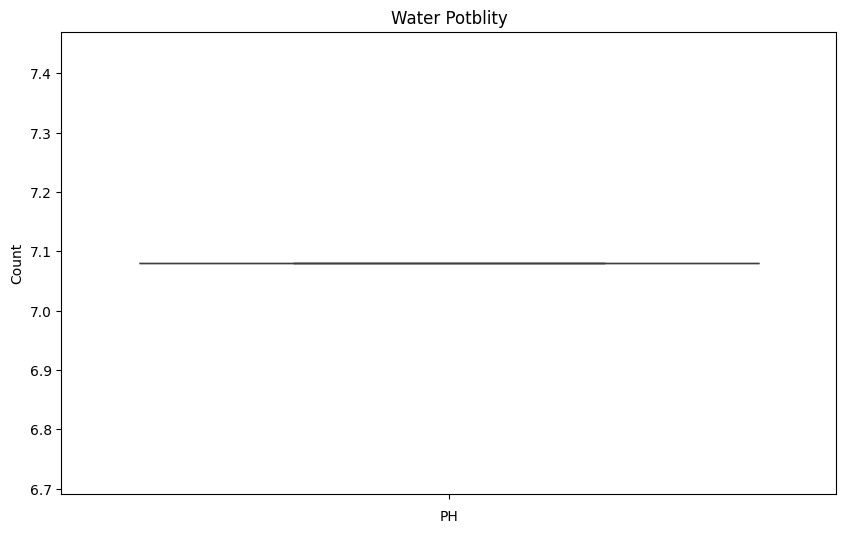

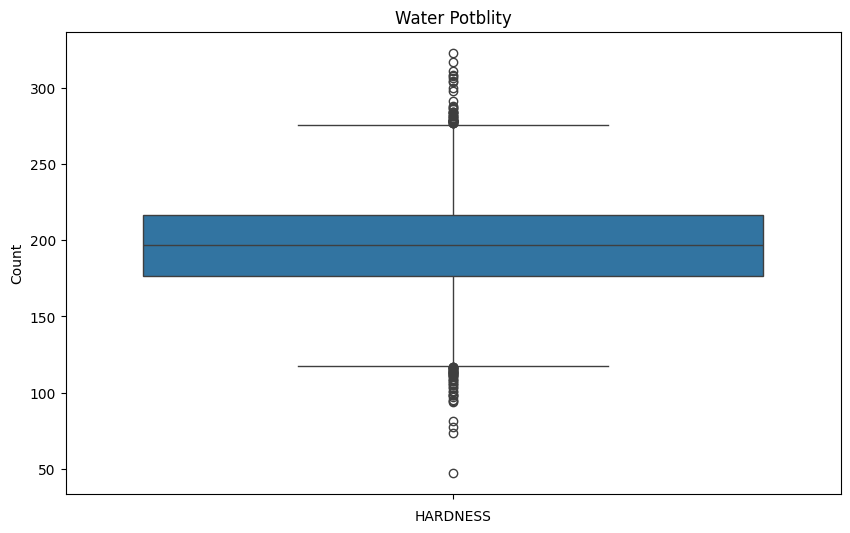

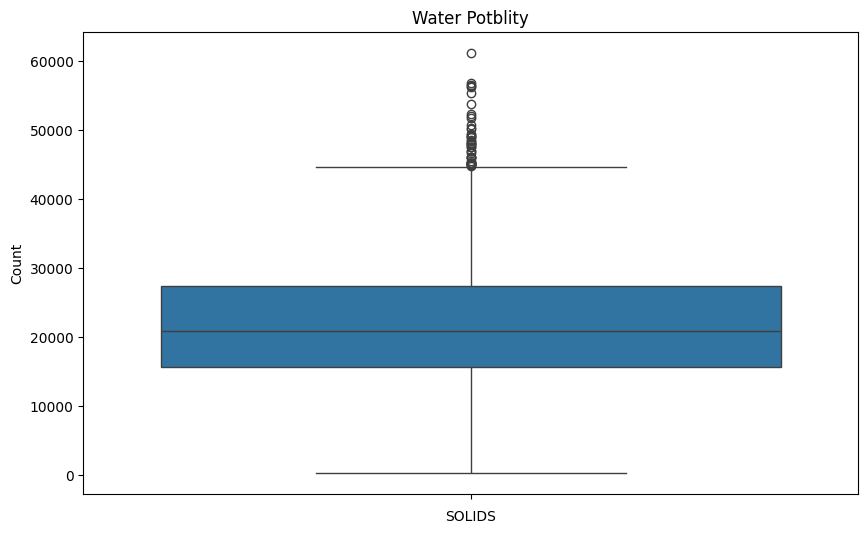

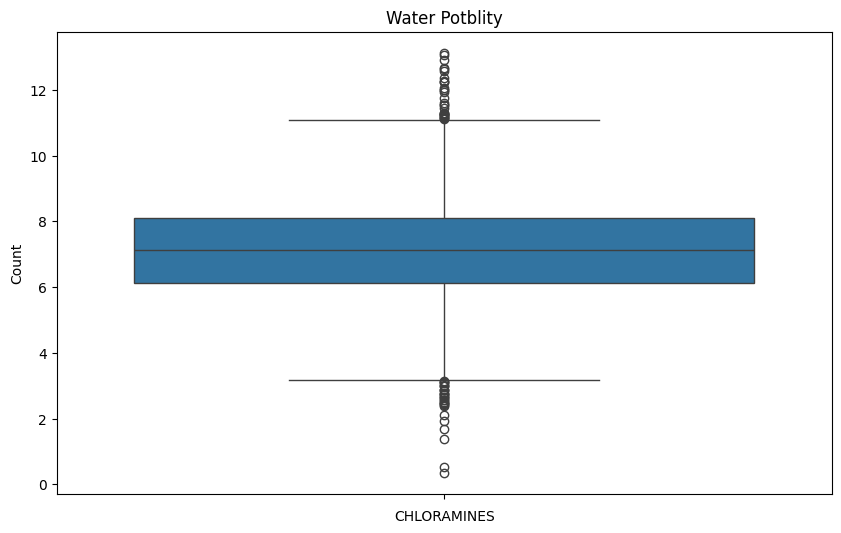

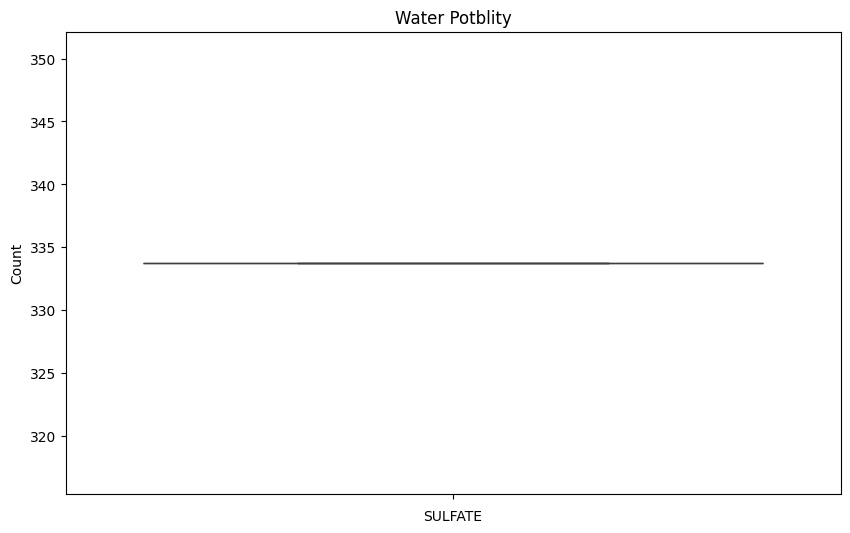

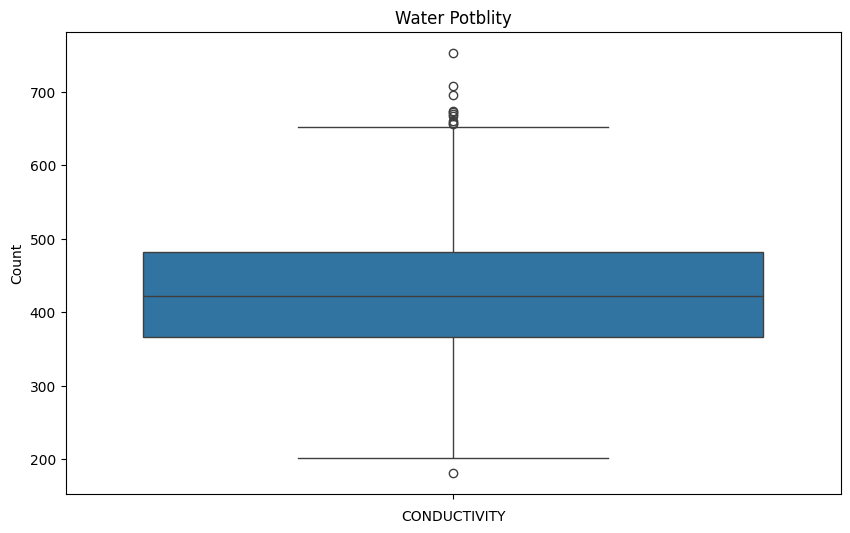

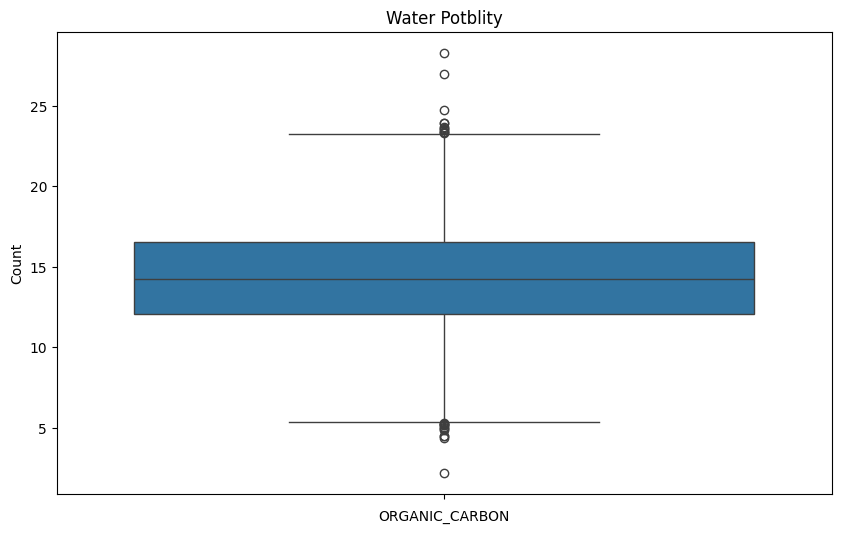

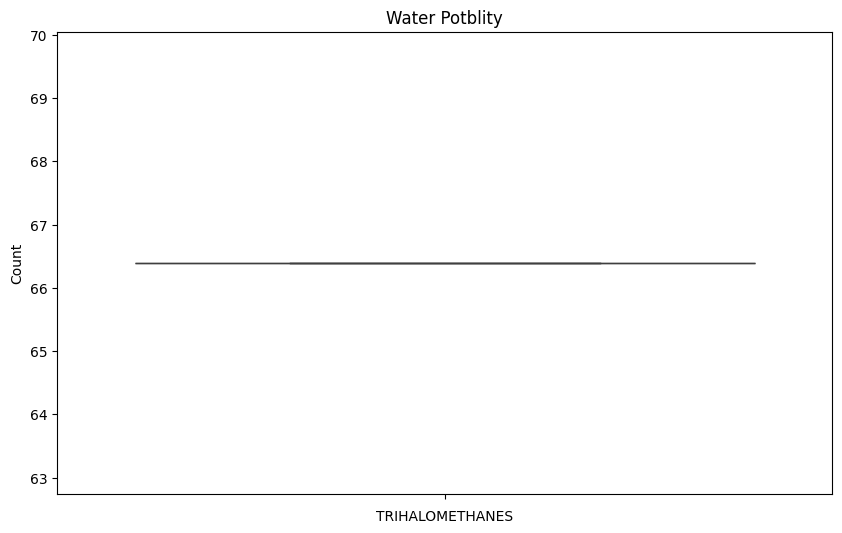

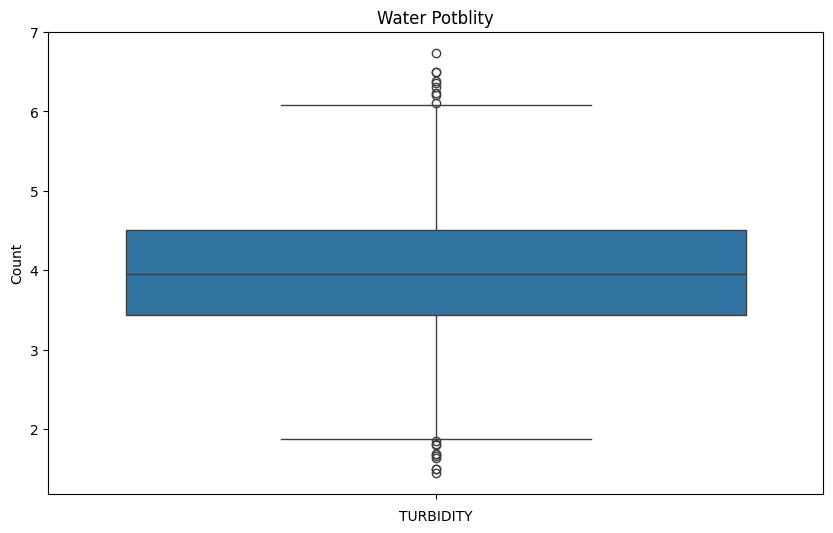

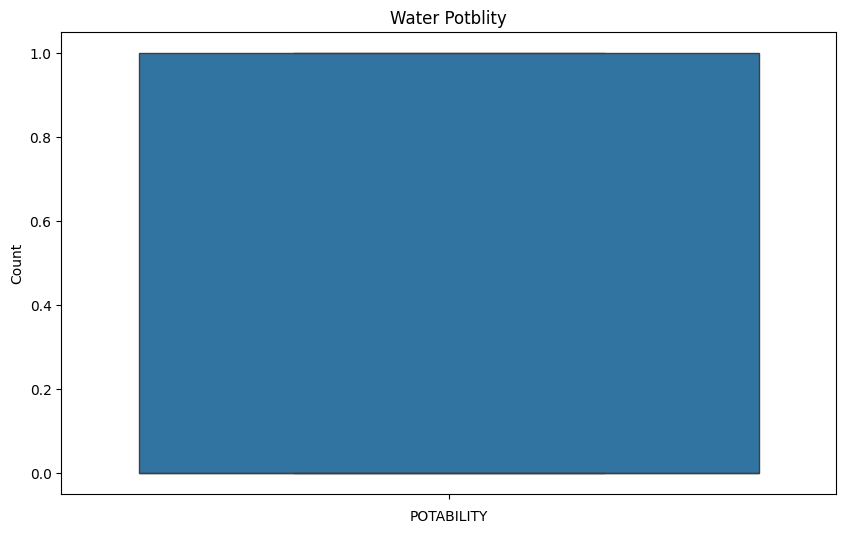

In [ ]:
for i in df.columns:
  if df[i].dtypes != "object":
    plt.figure(figsize=(10,6)),
    sns.boxplot(df[i])
    plt.title("Water Potblity")
    plt.xlabel(i)
    plt.ylabel("Count")
    plt.show

In [ ]:
data=['HARDNESS','SOLIDS','CHLORAMINES','CONDUCTIVITY','ORGANIC_CARBON','TURBIDITY']

In [ ]:
for i in data:
  Q1=df[i].quantile(0.25)
  Q3=df[i].quantile(0.75)
  IQR=Q3-Q1

  lb = Q1 - 1.5*IQR
  ub = Q3 + 1.5*IQR

  df=df[(lb<=df[i]) & (ub>=df[i])]


In [ ]:
df

,PH,HARDNESS,SOLIDS,CHLORAMINES,SULFATE,CONDUCTIVITY,ORGANIC_CARBON,TRIHALOMETHANES,TURBIDITY,POTABILITY
0,7.080795,204.890455,20791.318981,7.300212,333.775777,564.308654,10.379783,66.396293,2.963135,0
1,7.080795,129.422921,18630.057858,6.635246,333.775777,592.885359,15.180013,66.396293,4.500656,0
2,7.080795,224.236259,19909.541732,9.275884,333.775777,418.606213,16.868637,66.396293,3.055934,0
3,7.080795,214.373394,22018.417441,8.059332,333.775777,363.266516,18.436524,66.396293,4.628771,0
4,7.080795,181.101509,17978.986339,6.546600,333.775777,398.410813,11.558279,66.396293,4.075075,0
...,...,...,...,...,...,...,...,...,...,...
3270,7.080795,186.659040,26138.780191,7.747547,333.775777,415.886955,12.067620,66.396293,3.669712,1
3272,7.080795,193.553212,17329.802160,8.061362,333.775777,392.449580,19.903225,66.396293,2.798243,1
3273,7.080795,175.762646,33155.578218,7.350233,333.775777,432.044783,11.039070,66.396293,3.298875,1
3274,7.080795,230.603758,11983.869376,6.303357,333.775777,402.883113,11.168946,66.396293,4.708658,1


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x=df.iloc[:,:-1]
y=df['POTABILITY']

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [ ]:
from sklearn.preprocessing import RobustScaler

sc=RobustScaler()

x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

In [ ]:
# from sklearn.tree import DecisionTreeClassifier
# dc=DecisionTreeClassifier()
# dc.fit(x_train,y_train)
# y_pred=dc.predict(x_test)
from sklearn.svm import SVC
model=SVC()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
# from sklearn.ensemble import RandomForestClassifier

# model=RandomForestClassifier()
# model.fit(x_train,y_train)
# y_pred = model.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score
print("Accuracy Score :",accuracy_score(y_test,y_pred)*100)

Accuracy Score : 63.2183908045977
